このノートブックでは、ある物質Xの相図を作成する想定でPythonを用いたNIMOの使い方を説明します。

## NIMOのインストール
次のコマンドでNIMOをインストールすることができます。

In [ ]:
!pip install nimo

NIMOをインポートします。

In [ ]:
import nimo

## 物質Xの相図
ここでは、以下のような相図を持つ架空の物質Xの相図をPDCアルゴリズムで求めることにします。
- 三重点 (0 ℃, 5000 Pa) を通る直線より下の領域は気体
- 直線よりも上の領域で0℃未満では固体、0℃以上では液体
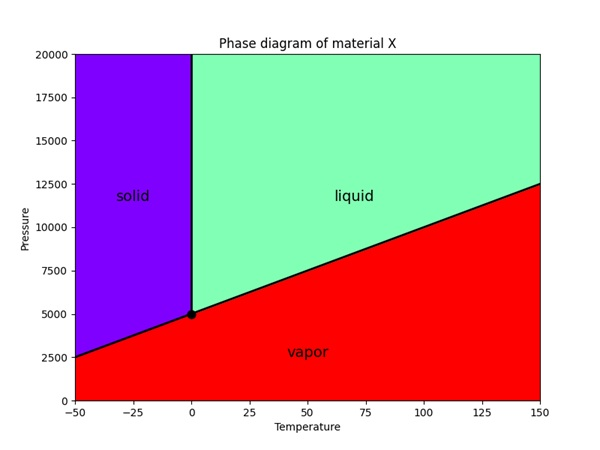

温度と圧力を与えると物質Xの相を返す実験装置のクラスを以下のように定義します。実際にNIMOを使う際は実際の実験装置に対応するクラスに置き換えてください。

In [ ]:
# SDLクラスの定義
class SampleSDL:
    def __init__(self):
        # 相図パラメータの定義
        self.t_triple = 0
        self.p_triple = 5000
        self.slope = 50

    def get_phase(self, temperature: float, pressure: float) -> int:
        """
        指定された温度・圧力に対応する相を求める
        0: 固相, 1: 液相, 2: 気相
        """
        boundary = self.slope * (temperature - self.t_triple) + self.p_triple

        if pressure < boundary:
            return 2
        else:
            if temperature < self.t_triple:
                return 0
            else:
                return 1

# SDLインスタンスの作成
sdl = SampleSDL()

## 実験条件の設定
NIMOではCSVファイルを用いて実験条件を設定します。

ここでは[NIMOチュートリアル](https://github.com/NIMS-DA/nimo-tutorial/)のGitHubレポジトリからサンプルファイルをダウンロードすることにします。

In [ ]:
!wget https://raw.githubusercontent.com/NIMS-DA/nimo/refs/heads/main/docs/ja/tutorial/candidates.csv

最初の10行を表示してみます。

In [ ]:
!head candidates.csv

candidates.csvには実験する可能性のある温度と圧力が網羅されています。予備実験で既に結果が分かっている行にはobjectiveを記入し、まだ実験を行っていない行のobjectiveは空欄にします。

[nimo.visualization.plot_phase_diagram.plot()](https://nims-da.github.io/nimo/ja/nimo.visualization.html#nimo.visualization.plot_phase_diagram.plot)関数を使って予備実験の結果に基づく相図を一度表示してみましょう。

In [ ]:
nimo.visualization.plot_phase_diagram.plot(input_file = "candidates.csv", fig_folder=".")

Google Colabの画面左側の「ファイル」をクリックすると、`phase_`から始まる画像ファイルと、`phase_diagram_`から始まる画像ファイルが生成されています。

`phase_`から始まる画像ファイルは予備実験で行った実験点を表しています。

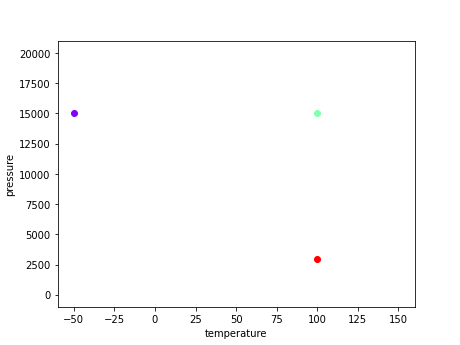

`phase_diagram_`から始まる画像ファイルは予備実験の結果から予想される相図を表しています。
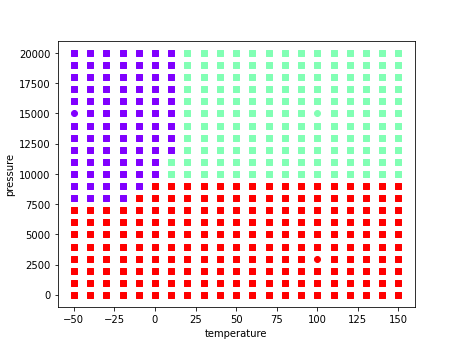

PDCアルゴリズムでは、この予想相図の中で予想が不確実な点を対象に実験を行います。

では実際にPDCアルゴリズムによる実験条件の設定を行ってみます。

In [ ]:
# 目的関数の数を指定
n_objectives = 1

#一度のサイクルで探索アルゴリズムが提案する条件数を指定
n_proposals = 1

# 実験条件をリスト化したファイルを指定
candidates_file = "./candidates.csv"

# 探索アルゴリズムが提案する条件を記載するファイルを指定
proposals_file = "./proposals.csv"

# 探索アルゴリズムの実行
nimo.selection(method = "PDC",
                input_file = candidates_file,
                output_file = proposals_file,
                num_objectives = n_objectives,
                num_proposals = n_proposals)

このコードを実行すると、`proposals.csv`にPDCアルゴリズムが設定した実験条件が出力されます。

In [ ]:
!cat proposals.csv

このCSVファイルを読み取って、実験を行うコードは以下の通りです。

In [ ]:
import csv

# 提案ファイルの読み込み
with open(proposals_file, newline="") as f:
    reader = csv.DictReader(f)

    # 提案ファイルの各行ごとに実験を実行
    objs = []  # 実験結果を格納するリスト
    for row in reader:
        temperature = float(row["temperature"])
        pressure = float(row["pressure"])
        # 実験の実行
        result = sdl.get_phase(temperature, pressure)
        objs.append(result)
        print(f"temperature: {temperature}, pressure: {pressure}, result: {result}")

この実験結果をもとに実験条件設定ファイルを更新します。

In [ ]:
# 実験条件ファイルの更新
nimo.output_update(input_file = proposals_file,
                    output_file = candidates_file,
                    num_objectives = n_objectives,
                    objective_values = objs)

更新された実験条件ファイルを使って相図を再描画します。


In [ ]:
nimo.visualization.plot_phase_diagram.plot(input_file = "candidates.csv", fig_folder=".")

このように、NIMOが提案した実験条件による実験と、その実験結果による実験条件ファイルの更新を繰り返すことで、NIMOによるクローズループ実験を実現することができます。

では、このループをさらに20回繰り返してみることにします。

In [ ]:
# サイクル数を指定
n_cycles = 20

for K in range(n_cycles):

    print("Start cycle", K+1)

    # 探索アルゴリズムの実行
    nimo.selection(method = "PDC",
                    input_file = candidates_file,
                    output_file = proposals_file,
                    num_objectives = n_objectives,
                    num_proposals = n_proposals)

    # 提案ファイルの読み込み
    with open(proposals_file, newline="") as f:
        reader = csv.DictReader(f)

        # 提案ファイルの各行ごとに実験を実行
        objs = []
        for row in reader:
            temperature = float(row["temperature"])
            pressure = float(row["pressure"])
            result = sdl.get_phase(temperature, pressure)
            objs.append(result)
            print(f"temperature: {temperature}, pressure: {pressure}, result: {result}")

    # 実験条件ファイルの更新
    nimo.output_update(input_file = proposals_file,
                        output_file = candidates_file,
                        num_objectives = n_objectives,
                        objective_values = objs)

    # 各サイクルの相図を出力
    nimo.visualization.plot_phase_diagram.plot(input_file = candidates_file, fig_folder=".")

最終的に得られた相図は、予備実験の結果に基づくものよりも真の相図に近いものになりました。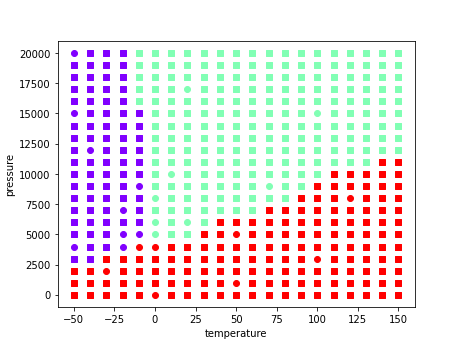